# Citrus-Diseases dataset audit

Going through the raw dataset before any training happens. Checking that the images actually
open, looking for duplicates, checking class balance and resolution consistency, and dumping
everything into a metadata csv so later notebooks don't have to redo this.

Imports. Everything here is already in the venv, nothing extra to install.

In [1]:
import os
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
from PIL import Image, UnidentifiedImageError
import imagehash
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import NearestNeighbors

sns.set_theme(style="whitegrid")

DATA_ROOT = r"C:\workstation\3RD YEAR\citrus_fruit\Citrus-Diseases"

Scanning the dataset folder to find the classes. Not assuming any class names, just reading the folder structure.

In [2]:
data_root = Path(DATA_ROOT)
image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".tiff", ".tif", ".webp"}

all_image_paths = [p for p in data_root.rglob("*") if p.is_file() and p.suffix.lower() in image_extensions]
print(f"Total image files found under {data_root}: {len(all_image_paths)}")

# class label = immediate parent folder name, works regardless of how deep the images are nested
class_counts_raw = Counter(p.parent.name for p in all_image_paths)
class_names = sorted(class_counts_raw.keys())

print(f"\nDiscovered {len(class_names)} classes:")
for cname in class_names:
    print(f"  {cname}: {class_counts_raw[cname]} files")

Total image files found under C:\workstation\3RD YEAR\citrus_fruit\Citrus-Diseases: 1704

Discovered 4 classes:
  aphids: 416 files
  gummosis: 462 files
  healthy: 367 files
  leaf_minnor: 459 files


Opening every image to make sure it actually loads, and computing a perceptual hash at the same time so we don't have to open each file twice.

In [3]:
records = []
corrupt_files = []

for path in tqdm(all_image_paths, desc="Reading images"):
    try:
        with Image.open(path) as img:
            img.load()  # forces full decode, catches truncated/corrupt files that Image.open() alone misses
            width, height = img.size
            fmt = img.format
            phash = imagehash.phash(img)
        filesize = path.stat().st_size
        records.append({
            "filepath": str(path),
            "class_label": path.parent.name,
            "width": width,
            "height": height,
            "filesize_bytes": filesize,
            "format": fmt,
            "phash": str(phash),
            "_phash_obj": phash,
        })
    except (UnidentifiedImageError, OSError, SyntaxError) as e:
        corrupt_files.append((str(path), str(e)))

print(f"Valid images: {len(records)}")
print(f"Corrupt/unreadable images: {len(corrupt_files)}")

Reading images: 100%|██████████| 1704/1704 [06:56<00:00,  4.10it/s]

Valid images: 1704
Corrupt/unreadable images: 0


Corrupt files, listed separately so they don't get buried in the main counts.

In [4]:
if corrupt_files:
    print(f"{len(corrupt_files)} corrupt/unreadable file(s):")
    for fp, err in corrupt_files:
        print(f"  {fp}\n    reason: {err}")
else:
    print("No corrupt files found.")

No corrupt files found.


Checking for duplicates with perceptual hashing. Exact matches first (identical phash), then near-duplicates within a small hamming distance.

In [5]:
# exact duplicates: identical phash string
hash_to_paths = defaultdict(list)
for rec in records:
    hash_to_paths[rec["phash"]].append(rec["filepath"])

is_duplicate_of = {rec["filepath"]: "" for rec in records}
duplicate_type = {rec["filepath"]: "" for rec in records}

for h, paths in hash_to_paths.items():
    if len(paths) > 1:
        original = paths[0]
        for dup in paths[1:]:
            is_duplicate_of[dup] = original
            duplicate_type[dup] = "exact"

exact_dup_count = sum(1 for v in duplicate_type.values() if v == "exact")
print(f"Exact duplicates found: {exact_dup_count}")

Exact duplicates found: 91


Near-duplicates: same idea but allowing a few bits of difference, since two photos of the same leaf a second apart won't hash identically.

In [6]:
NEAR_DUP_HAMMING_THRESHOLD = 5  # out of 64 bits, a common cutoff for "visually near-identical"

remaining = [rec for rec in records if duplicate_type[rec["filepath"]] == ""]
near_dup_count = 0

if len(remaining) > 1:
    hash_bits = np.array([rec["_phash_obj"].hash.flatten() for rec in remaining])

    # brute force is fine at this dataset size; sklearn's hamming metric is the fraction of differing bits
    nn = NearestNeighbors(metric="hamming", algorithm="brute")
    nn.fit(hash_bits)
    radius = NEAR_DUP_HAMMING_THRESHOLD / hash_bits.shape[1]
    neighbor_indices = nn.radius_neighbors(hash_bits, radius=radius, return_distance=False)

    for i, neighbors in enumerate(neighbor_indices):
        current_path = remaining[i]["filepath"]
        if duplicate_type[current_path] != "":
            continue
        earlier = [j for j in neighbors if j < i and duplicate_type[remaining[j]["filepath"]] == ""]
        if earlier:
            original_path = remaining[earlier[0]]["filepath"]
            is_duplicate_of[current_path] = original_path
            duplicate_type[current_path] = "near"
            near_dup_count += 1

print(f"Near-duplicates found: {near_dup_count}")
print(f"Total duplicates (exact + near): {exact_dup_count + near_dup_count}")

Near-duplicates found: 596
Total duplicates (exact + near): 687


Quick breakdown of whether duplicates sit inside one class or leak across classes, and a few example pairs to spot-check.

In [7]:
path_to_class = {rec["filepath"]: rec["class_label"] for rec in records}

within_class = sum(1 for fp, orig in is_duplicate_of.items() if orig and path_to_class[fp] == path_to_class[orig])
cross_class = sum(1 for fp, orig in is_duplicate_of.items() if orig and path_to_class[fp] != path_to_class[orig])
print(f"Within-class duplicates: {within_class}")
print(f"Cross-class duplicates: {cross_class}")

example_pairs = [(fp, orig) for fp, orig in is_duplicate_of.items() if orig][:10]
print("\nExample duplicate pairs:")
for fp, orig in example_pairs:
    print(f"  {fp}\n    -> duplicate of: {orig}")

Within-class duplicates: 687
Cross-class duplicates: 0

Example duplicate pairs:
  C:\workstation\3RD YEAR\citrus_fruit\Citrus-Diseases\aphids\aphids_006.jpg
    -> duplicate of: C:\workstation\3RD YEAR\citrus_fruit\Citrus-Diseases\aphids\aphids_005.jpg
  C:\workstation\3RD YEAR\citrus_fruit\Citrus-Diseases\aphids\aphids_018.jpg
    -> duplicate of: C:\workstation\3RD YEAR\citrus_fruit\Citrus-Diseases\aphids\aphids_017.jpg
  C:\workstation\3RD YEAR\citrus_fruit\Citrus-Diseases\aphids\aphids_020.jpg
    -> duplicate of: C:\workstation\3RD YEAR\citrus_fruit\Citrus-Diseases\aphids\aphids_019.jpg
  C:\workstation\3RD YEAR\citrus_fruit\Citrus-Diseases\aphids\aphids_021.jpg
    -> duplicate of: C:\workstation\3RD YEAR\citrus_fruit\Citrus-Diseases\aphids\aphids_019.jpg
  C:\workstation\3RD YEAR\citrus_fruit\Citrus-Diseases\aphids\aphids_024.jpg
    -> duplicate of: C:\workstation\3RD YEAR\citrus_fruit\Citrus-Diseases\aphids\aphids_003.jpg
  C:\workstation\3RD YEAR\citrus_fruit\Citrus-Diseases

Putting it all into one dataframe and saving it out so the training notebook can just load this instead of re-scanning everything.

In [8]:
df = pd.DataFrame([
    {
        "filepath": rec["filepath"],
        "class_label": rec["class_label"],
        "width": rec["width"],
        "height": rec["height"],
        "filesize_bytes": rec["filesize_bytes"],
        "format": rec["format"],
        "phash": rec["phash"],
        "is_duplicate_of": is_duplicate_of[rec["filepath"]],
    }
    for rec in records
])

df.to_csv("metadata.csv", index=False)
print(f"Saved metadata.csv with {len(df)} rows")
df.head()

Saved metadata.csv with 1704 rows


,filepath,class_label,width,height,filesize_bytes,format,phash,is_duplicate_of
0,C:\workstation\3RD YEAR\citrus_fruit\Citrus-Di...,aphids,4284,5712,1369832,JPEG,9996f6b9acd28d80,
1,C:\workstation\3RD YEAR\citrus_fruit\Citrus-Di...,aphids,3024,4032,1235446,JPEG,99b3f6b8ad528c84,
2,C:\workstation\3RD YEAR\citrus_fruit\Citrus-Di...,aphids,3024,4032,1234044,JPEG,99b5f6b1ad428ca4,
3,C:\workstation\3RD YEAR\citrus_fruit\Citrus-Di...,aphids,3024,4032,1263473,JPEG,99b7f6f18c408d85,
4,C:\workstation\3RD YEAR\citrus_fruit\Citrus-Di...,aphids,3024,4032,1281310,JPEG,9cb5f2f58c4a8ca4,


Class balance.

In [9]:
class_dist = df["class_label"].value_counts().sort_index()
print("Class distribution:")
print(class_dist)

imbalance_ratio = class_dist.max() / class_dist.min()
print(f"\nImbalance ratio (largest class / smallest class): {imbalance_ratio:.2f}")
if imbalance_ratio > 3:
    print("Ratio is above 3x, worth accounting for later (class weights, oversampling, etc).")

Class distribution:
class_label
aphids         416
gummosis       462
healthy        367
leaf_minnor    459
Name: count, dtype: int64

Imbalance ratio (largest class / smallest class): 1.26


A few sanity check plots before moving on.

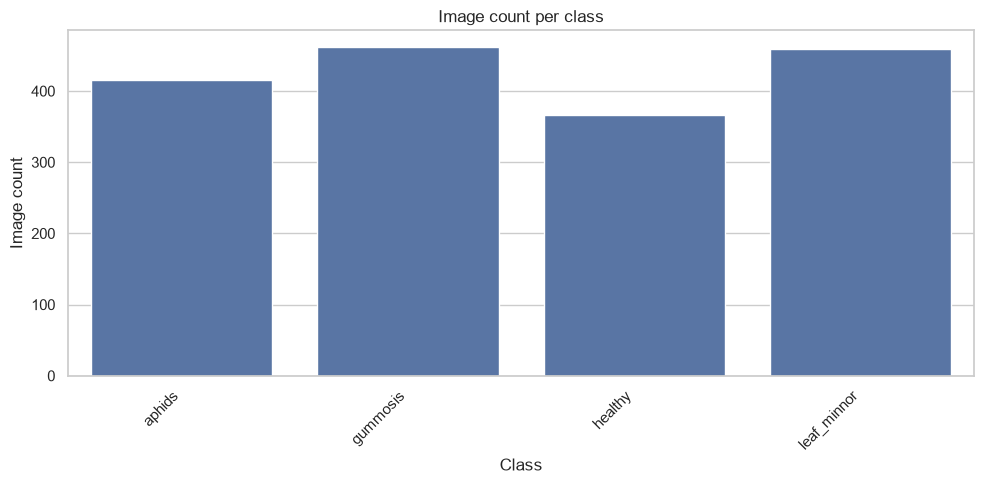

In [10]:
plt.figure(figsize=(10, 5))
sns.barplot(x=class_dist.index, y=class_dist.values)
plt.xticks(rotation=45, ha="right")
plt.xlabel("Class")
plt.ylabel("Image count")
plt.title("Image count per class")
plt.tight_layout()
plt.show()

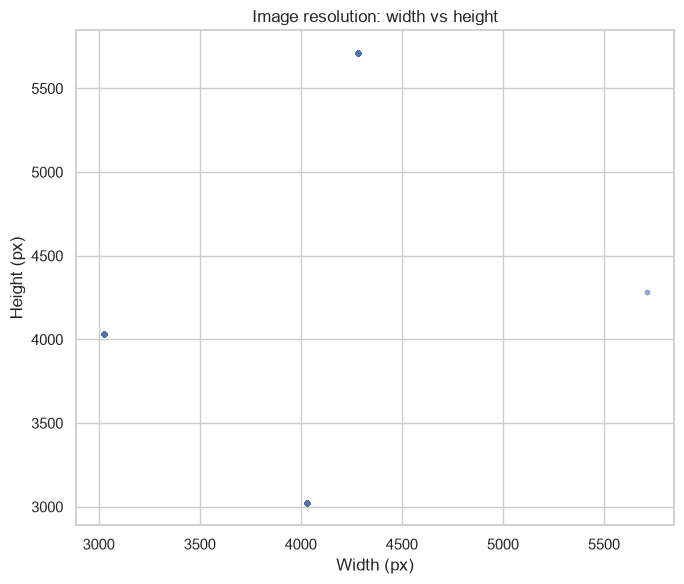

In [11]:
plt.figure(figsize=(7, 6))
plt.scatter(df["width"], df["height"], alpha=0.3, s=10)
plt.xlabel("Width (px)")
plt.ylabel("Height (px)")
plt.title("Image resolution: width vs height")
plt.tight_layout()
plt.show()

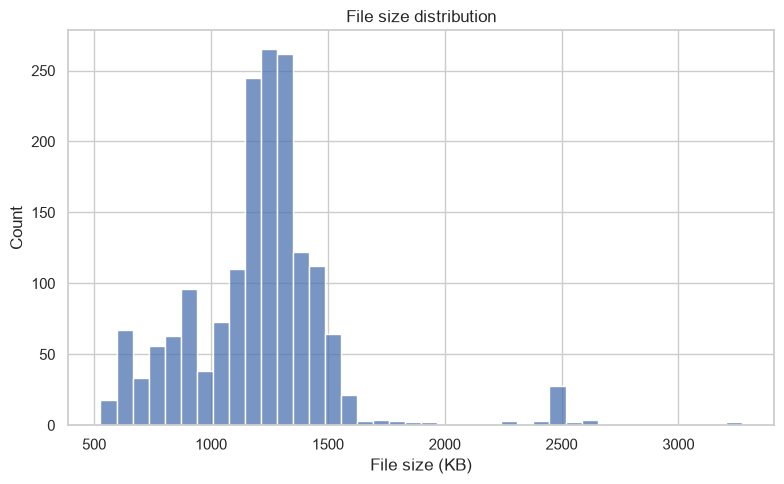

In [12]:
plt.figure(figsize=(8, 5))
sns.histplot(df["filesize_bytes"] / 1024, bins=40)
plt.xlabel("File size (KB)")
plt.ylabel("Count")
plt.title("File size distribution")
plt.tight_layout()
plt.show()

Summary of everything above.

In [13]:
total_images = len(df)
num_classes = df["class_label"].nunique()
corrupt_count = len(corrupt_files)
total_dup_count = exact_dup_count + near_dup_count
total_size_bytes = df["filesize_bytes"].sum()

res_counts = df.groupby(["width", "height"]).size()
most_common_res = res_counts.idxmax()
most_common_res_count = res_counts.max()

print("=" * 55)
print("DATA CARD - Citrus-Diseases dataset audit")
print("=" * 55)
print(f"Total valid images: {total_images}")
print(f"Number of classes: {num_classes}")
print("Classes:")
for cname in sorted(df["class_label"].unique()):
    print(f"  - {cname}: {class_dist[cname]} images")
print(f"\nCorrupt/unreadable files skipped: {corrupt_count}")
print(f"Duplicate images (exact + near): {total_dup_count}  (exact: {exact_dup_count}, near: {near_dup_count})")
print(f"\nResolution range: {df['width'].min()}x{df['height'].min()} to {df['width'].max()}x{df['height'].max()}")
print(f"Most common resolution: {most_common_res[0]}x{most_common_res[1]} ({most_common_res_count} images)")
print(f"\nTotal dataset size on disk: {total_size_bytes / (1024**2):.2f} MB")
print("=" * 55)

DATA CARD - Citrus-Diseases dataset audit
Total valid images: 1704
Number of classes: 4
Classes:
  - aphids: 416 images
  - gummosis: 462 images
  - healthy: 367 images
  - leaf_minnor: 459 images

Corrupt/unreadable files skipped: 0
Duplicate images (exact + near): 687  (exact: 91, near: 596)

Resolution range: 3024x3024 to 5712x5712
Most common resolution: 3024x4032 (1378 images)

Total dataset size on disk: 2011.28 MB
